<a href="https://colab.research.google.com/github/JamilRez53/Adversarial-Attacks-on-forcasting/blob/main/LSTM_Load_Forcasting_ISO_NE_Data_set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM-based Short-Term Load Forecasting
### (adapted for the Kaggle "ISO-NE Smart City Energy Dataset")

Implements the three classical (non-quantum) models described in:

> Sahay, K.B. & Singh, M. (2026). *"Quantum-Inspired Deep Learning Model for
> Short-Term Load Forecasting in Smart Grid Energy Management."* IEEE Access.

**Models implemented (in order of increasing sophistication):**
1. **Base LSTM** — single 64-unit LSTM layer + dense output
2. **Stacked LSTM** — 3 LSTM layers (64, 64, 128 units) in series
3. **Enhanced Stacked LSTM** — same as (2) + a normalization layer placed immediately before the final (128-unit) LSTM layer

> **Note:** The Quantum-Inspired Hadamard mixing step (QI-LSTM) is intentionally **not** implemented here, per request.

### Dataset
This notebook is wired up for the Kaggle dataset `datasetengineer/isone-smart-city-energy-dataset`,
downloaded via `kagglehub`. Its columns already include several of the paper's required
inputs pre-computed (hour, day-of-week, weekend flag), so the feature-engineering step
below reuses those instead of recomputing them, and only builds the lagged-load features
(24/48/72/168/336h) that aren't already present.

## 1. Download & inspect the dataset

In [ ]:
import os
import kagglehub

# path = kagglehub.dataset_download("datasetengineer/isone-smart-city-energy-dataset")
df = pd.read_excel(
    '2025_smd_hourly.xlsx',
    sheet_name="ISO NE CA"
)

# print("Path to dataset files:", path)
# print("Files:", os.listdir(path))
# print(xls.sheet_names)
df.dtypes

,0
Date,datetime64[ns]
Hr_End,object
DA_Demand,float64
RT_Demand,float64
DA_LMP,float64
DA_EC,float64
DA_CC,float64
DA_MLC,float64
RT_LMP,float64
RT_EC,float64


## 2. Imports

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import r2_score
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import timedelta

## 3. Config — column mapping for this dataset

In [ ]:
DATE_COL = "Date"        # calendar date (midnight-stamped)
HREND_COL = "Hr_End"     # hour-ending label, string '01'..'24'
TS_COL = "Timestamp"     # constructed below: Date + (Hr_End - 1) hours

LOAD_COL = "System_Load"     # target to forecast (actual metered system load, MW)
DRYBULB_COL = "Dry_Bulb"
DEWPOINT_COL = "Dew_Point"

# Calendar features are NOT present in this file, so we derive them
# from the constructed Timestamp column instead of reusing dataset columns.
HOUR_COL = "Hour"
WEEKDAY_COL = "Weekday"
WEEKEND_COL = "IsWeekend"

# Train/test split. The paper used a fixed date-based split (Apr 2019-Dec 2023
# train / Jan-Dec 2024 test) on ISO-NE's multi-year data. This workbook only
# covers calendar year 2025, so we fall back to a chronological 80/20 split
# within the single year (still strictly time-ordered, no leakage).
TRAIN_FRAC = 0.80

LAG_HOURS = [24, 48, 72, 168, 336]   # matches the paper's lagged-load inputs
TIMESTEPS = 24                        # sequence length fed to the LSTM

# Training hyperparameters (matches paper's MATLAB settings)
EPOCHS = 20
BATCH_SIZE = 32
LEARNING_RATE = 0.001


## 4. Load data & check the date range

Run this first to confirm how much history the dataset actually covers, then decide
whether to use a fixed date-based split (like the paper) or the fallback chronological
fraction split above.

In [ ]:
raw = pd.read_excel(
    '2025_smd_hourly.xlsx',
    sheet_name="ISO NE CA"
)
raw[DATE_COL] = pd.to_datetime(raw[DATE_COL])

# Hr_End is normally '01'..'24', but ISO-NE marks the repeated hour on the
# DST "fall back" day with a trailing 'X' (e.g. '02X') -- strip any non-digit
# characters before casting to int.
raw["_hour_int"] = (
    raw[HREND_COL].astype(str).str.extract(r"(\d+)")[0].astype(int)
)

# Hour-ending 24 == 23:00-24:00 of the same calendar day -> hour-of-day 23
raw[TS_COL] = raw[DATE_COL] + pd.to_timedelta(raw["_hour_int"] - 1, unit="h")

# The DST fall-back duplicate ('02X') produces a repeated Timestamp -- keep the
# first occurrence so the series stays one-row-per-hour.
raw = raw.sort_values(TS_COL).drop_duplicates(subset=[TS_COL]).reset_index(drop=True)

raw[HOUR_COL] = raw[TS_COL].dt.hour
raw[WEEKDAY_COL] = raw[TS_COL].dt.dayofweek          # 0=Monday ... 6=Sunday
raw[WEEKEND_COL] = (raw[WEEKDAY_COL] >= 5).astype(int)

print("Rows:", len(raw))
print("Date range:", raw[TS_COL].min(), "to", raw[TS_COL].max())
raw

Rows: 8759
Date range: 2025-01-01 00:00:00 to 2025-12-31 23:00:00


,Date,Hr_End,DA_Demand,RT_Demand,DA_LMP,DA_EC,DA_CC,DA_MLC,RT_LMP,RT_EC,...,Reg_Capacity_Price,Min_5min_RSP,Max_5min_RSP,Min_5min_RCP,Max_5min_RCP,_hour_int,Timestamp,Hour,Weekday,IsWeekend
0,2025-01-01,01,11020.2,11169.703,37.21,37.17,0.0,0.04,55.69,55.51,...,37.500000,0.00,0.01,0.00,50.00,1,2025-01-01 00:00:00,0,2,0
1,2025-01-01,02,10939.3,10788.139,35.09,35.02,0.0,0.07,41.96,41.78,...,8.333333,0.00,0.01,0.00,50.00,2,2025-01-01 01:00:00,1,2,0
2,2025-01-01,03,10302.3,10457.288,31.62,31.58,0.0,0.04,33.31,33.17,...,0.000000,0.00,0.00,0.00,0.00,3,2025-01-01 02:00:00,2,2,0
3,2025-01-01,04,10113.9,10266.686,30.05,30.00,0.0,0.05,32.53,32.38,...,0.000000,0.00,0.00,0.00,0.00,4,2025-01-01 03:00:00,3,2,0
4,2025-01-01,05,9979.7,10295.384,28.57,28.50,0.0,0.07,31.70,31.51,...,0.000000,0.00,0.00,0.00,0.00,5,2025-01-01 04:00:00,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8754,2025-12-31,20,16484.8,16411.900,178.17,177.94,0.0,0.23,80.23,79.86,...,8.008333,0.00,0.05,0.00,9.61,20,2025-12-31 19:00:00,19,2,0
8755,2025-12-31,21,15979.7,15805.841,173.12,172.86,0.0,0.26,78.63,78.26,...,8.030833,0.05,0.05,7.84,9.61,21,2025-12-31 20:00:00,20,2,0
8756,2025-12-31,22,15331.4,15206.881,151.55,151.42,0.0,0.13,84.82,84.42,...,16.853333,0.00,0.50,0.00,19.44,22,2025-12-31 21:00:00,21,2,0
8757,2025-12-31,23,14528.6,14544.393,144.01,143.90,0.0,0.11,78.47,78.11,...,11.808333,0.00,0.25,0.00,14.17,23,2025-12-31 22:00:00,22,2,0


**Data Visualization**

In [ ]:
month_names = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

In [ ]:
raw['Timestamp'] = pd.to_datetime(raw['Timestamp'])
raw['Year'] = raw['Timestamp'].dt.year
raw['Month'] = pd.to_datetime(raw['Timestamp']).dt.month

In [ ]:
Columns = [LOAD_COL,DRYBULB_COL]
monthly_load = (
    raw.groupby(['Month','Year'])[Columns]
    .sum()
    .reset_index()
)
monthly_load['Month'] = monthly_load['Month'].apply(lambda x: month_names[x-1])
monthly_load

,Month,Year,System_Load,Dry_Bulb
0,January,2025,11389413,20065
1,February,2025,9960154,19364
2,March,2025,9329877,30221
3,April,2025,8255730,35721
4,May,2025,8423961,43252
5,June,2025,9978016,49690
6,July,2025,12180867,55616
7,August,2025,10329589,51572
8,September,2025,8827744,46611
9,October,2025,8654289,40157


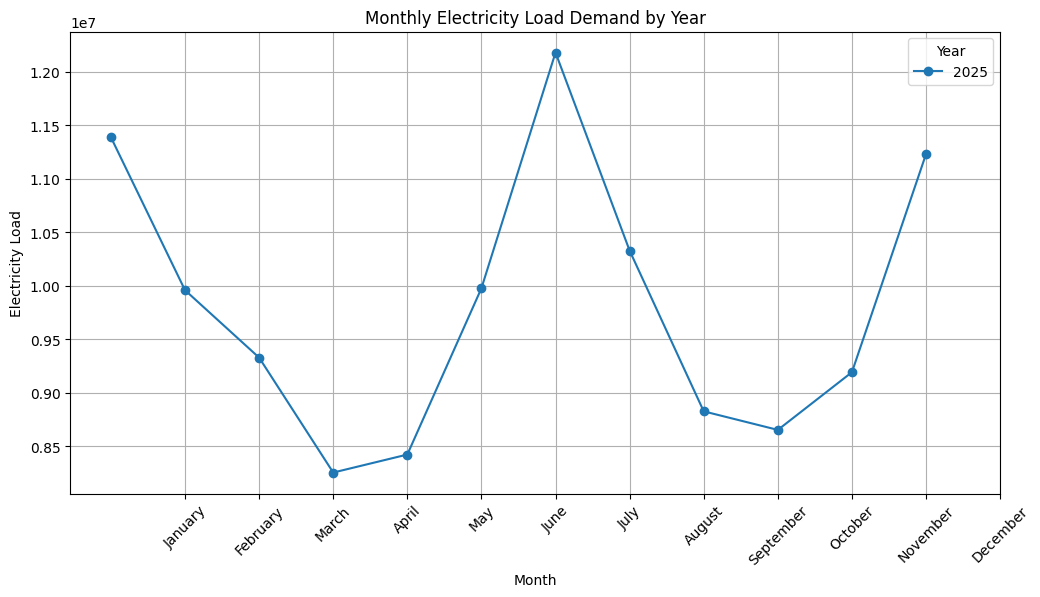

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))

for year in monthly_load['Year'].unique():

    yearly_data = monthly_load[
        monthly_load['Year'] == year
    ]

    plt.plot(
        yearly_data['Month'],
        yearly_data[LOAD_COL],
        marker='o',
        label=str(year)
    )

plt.xlabel('Month')
plt.ylabel('Electricity Load')
plt.title('Monthly Electricity Load Demand by Year')

plt.xticks(
    range(1, 13),
    month_names,
    rotation=45
)

plt.legend(title='Year')
plt.grid(True)

plt.show()

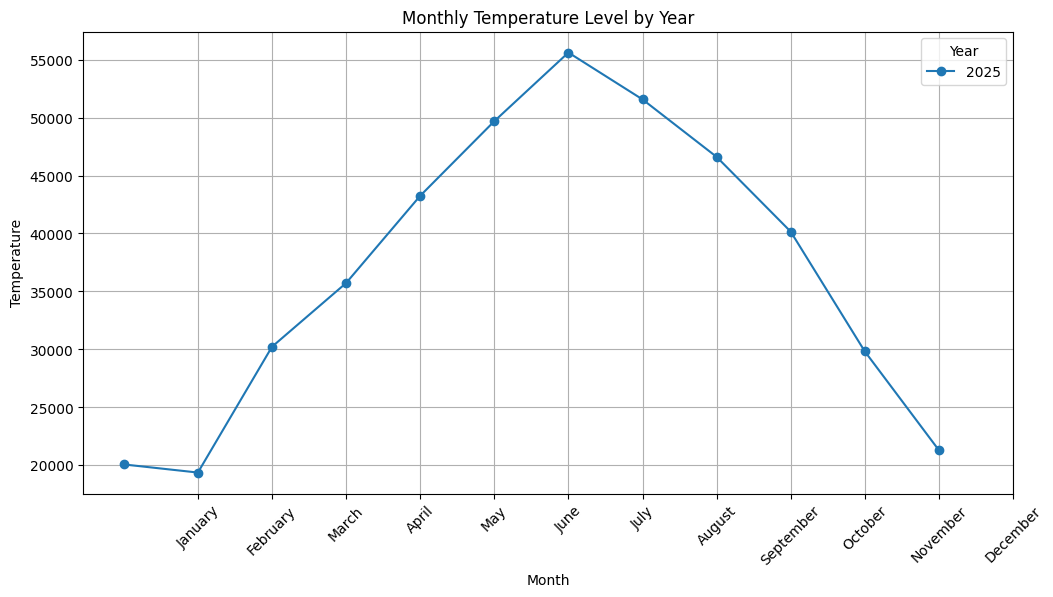

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))

for year in monthly_load['Year'].unique():

    yearly_data = monthly_load[
        monthly_load['Year'] == year
    ]

    plt.plot(
        yearly_data['Month'],
        yearly_data[DRYBULB_COL],
        marker='o',
        label=str(year)
    )

plt.xlabel('Month')
plt.ylabel('Temperature')
plt.title('Monthly Temperature Level by Year')

plt.xticks(
    range(1, 13),
    month_names,
    rotation=45
)

plt.legend(title='Year')
plt.grid(True)

plt.show()

## 5. Feature engineering

In [ ]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """Reuse the dataset's existing calendar columns and add lagged-load features."""
    df = df.copy()
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df = df.sort_values(DATE_COL).reset_index(drop=True)

    for lag in LAG_HOURS:
        df[f"load_lag_{lag}h"] = df[LOAD_COL].shift(lag)

    df = df.dropna(subset=[f"load_lag_{lag}h" for lag in LAG_HOURS] + [LOAD_COL, DRYBULB_COL, DEWPOINT_COL])
    df = df.reset_index(drop=True)
    return df


FEATURE_COLS = [DRYBULB_COL, DEWPOINT_COL, HOUR_COL, WEEKDAY_COL, WEEKEND_COL] + [
    f"load_lag_{lag}h" for lag in LAG_HOURS
]

df = build_features(raw)
print("Rows after lag dropna:", len(df))
df[FEATURE_COLS + [LOAD_COL]].head()

Rows after lag dropna: 8423


,Dry_Bulb,Dew_Point,Hour,Weekday,IsWeekend,load_lag_24h,load_lag_48h,load_lag_72h,load_lag_168h,load_lag_336h,System_Load
0,29,6,13,2,0,14520.0,15533.0,13879.0,16338.0,11402.0,15096
1,21,9,22,2,0,15181.0,15853.0,14688.0,17178.0,11777.0,15522
2,22,8,21,2,0,16255.0,16618.0,15938.0,18340.0,12510.0,16618
3,22,8,20,2,0,17139.0,17346.0,16955.0,19183.0,13387.0,17461
4,23,8,19,2,0,17696.0,17159.0,16899.0,19073.0,14103.0,18018


## 6. Train/test split

In [ ]:
# Chronological split (adjust to fixed dates if the range matches the paper's window)
split_idx = int(len(df) * TRAIN_FRAC)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

print(f"Train rows: {len(train_df)}   ({train_df[DATE_COL].min()} to {train_df[DATE_COL].max()})")
print(f"Test rows:  {len(test_df)}   ({test_df[DATE_COL].min()} to {test_df[DATE_COL].max()})")

Train rows: 6738   (2025-01-15 00:00:00 to 2025-10-22 00:00:00)
Test rows:  1685   (2025-10-22 00:00:00 to 2025-12-31 00:00:00)


## 7. Normalization & sequence helpers

In [ ]:
def zscore_fit(train_arr: np.ndarray):
    mu = train_arr.mean(axis=0)
    sigma = train_arr.std(axis=0)
    sigma[sigma == 0] = 1.0
    return mu, sigma


def zscore_apply(arr: np.ndarray, mu, sigma):
    return (arr - mu) / sigma


def zscore_inverse(arr: np.ndarray, mu, sigma):
    return arr * sigma + mu


def make_sequences(X: np.ndarray, y: np.ndarray, timesteps: int = 24):
    """Turn a flat feature matrix into overlapping sequences for the LSTM."""
    Xs, ys = [], []
    for i in range(timesteps, len(X)):
        Xs.append(X[i - timesteps:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

## 8. Normalize & build sequences

In [ ]:
X_train_raw = train_df[FEATURE_COLS].values.astype(float)
y_train_raw = train_df[LOAD_COL].values.reshape(-1, 1).astype(float)
X_test_raw = test_df[FEATURE_COLS].values.astype(float)
y_test_raw = test_df[LOAD_COL].values.reshape(-1, 1).astype(float)

# Z-score normalization (fit on train only, as in the paper)
x_mu, x_sigma = zscore_fit(X_train_raw)
y_mu, y_sigma = zscore_fit(y_train_raw)

X_train = zscore_apply(X_train_raw, x_mu, x_sigma)
y_train = zscore_apply(y_train_raw, y_mu, y_sigma).flatten()
X_test = zscore_apply(X_test_raw, x_mu, x_sigma)
y_test = zscore_apply(y_test_raw, y_mu, y_sigma).flatten()

X_train_seq, y_train_seq = make_sequences(X_train, y_train, TIMESTEPS)
X_test_seq, y_test_seq = make_sequences(X_test, y_test, TIMESTEPS)

input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
print("Input shape:", input_shape)
print("Train sequences:", X_train_seq.shape, " Test sequences:", X_test_seq.shape)

Input shape: (24, 10)
Train sequences: (6714, 24, 10)  Test sequences: (1661, 24, 10)


In [ ]:
def hadamard_mix(X: np.ndarray) -> np.ndarray:
    """Apply the paper's pairwise Hadamard mixing (Eq. 1-2) to a 2D array of
    Z-score-normalized features, shape (n_samples, n_features).

    For each consecutive feature pair (x_2i-1, x_2i):
        x'_2i-1 = (x_2i-1 + x_2i) / sqrt(2)
        x'_2i   = (x_2i-1 - x_2i) / sqrt(2)

    If n_features is odd, the last column is passed through unchanged.
    This is parameter-free and norm-preserving (an orthogonal transform).
    """
    X = np.asarray(X, dtype=float)
    n_samples, n_features = X.shape
    X_mixed = X.copy()

    n_pairs = n_features // 2
    for i in range(n_pairs):
        a = X[:, 2 * i]
        b = X[:, 2 * i + 1]
        X_mixed[:, 2 * i] = (a + b) / np.sqrt(2)
        X_mixed[:, 2 * i + 1] = (a - b) / np.sqrt(2)
    # odd leftover feature (not the case here: n_features == 10) is left as-is

    return X_mixed


# Sanity check: Hadamard mixing preserves the Euclidean norm of each row
_sample = X_train[:5]
_mixed_sample = hadamard_mix(_sample)
print("Norms before:", np.linalg.norm(_sample, axis=1))
print("Norms after: ", np.linalg.norm(_mixed_sample, axis=1))

# Apply to the full (already normalized) train/test feature matrices
X_train_qi = hadamard_mix(X_train)
X_test_qi = hadamard_mix(X_test)

X_train_seq_qi, y_train_seq_qi = make_sequences(X_train_qi, y_train, TIMESTEPS)
X_test_seq_qi, y_test_seq_qi = make_sequences(X_test_qi, y_test, TIMESTEPS)

print("QI-mixed train sequences:", X_train_seq_qi.shape, " test sequences:", X_test_seq_qi.shape)


Norms before: [3.0061918  3.65085105 3.95392545 4.28525967 4.24779838]
Norms after:  [3.0061918  3.65085105 3.95392545 4.28525967 4.24779838]
QI-mixed train sequences: (6714, 24, 10)  test sequences: (1661, 24, 10)


## 9. Metrics (Equations 5, 6, 7 in the paper)

In [ ]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def r2(y_true, y_pred):
    return r2_score(y_true, y_pred)


def evaluate(y_true, y_pred, name):
    m, a, r = mape(y_true, y_pred), mae(y_true, y_pred), r2(y_true, y_pred)
    print(f"[{name}] MAPE = {m:.4f}%   MAE = {a:.4f} kW   R2 = {r:.4f}")
    return {"model": name, "MAPE (%)": m, "MAE (kW)": a, "R2": r}

## 10. Model architectures

In [ ]:
def build_base_lstm(input_shape):
    """Single 64-unit LSTM layer + dense regression output (~19,265 params)."""
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss="mse")
    return model


def build_stacked_lstm(input_shape):
    """Three LSTM layers (64, 64, 128 units) in series (~151,169 params)."""
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        LSTM(64, return_sequences=True),
        LSTM(128),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss="mse")
    return model


def build_enhanced_stacked_lstm(input_shape):
    """Stacked LSTM + normalization layer placed immediately before the
    final (128-unit) LSTM layer (~151,297 params)."""
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        LSTM(64, return_sequences=True),
        BatchNormalization(),
        LSTM(128),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss="mse")
    return model

def build_qi_lstm(input_shape):
    """QI-LSTM: identical backbone to the Enhanced Stacked LSTM (64, 64, 128
    units + normalization before the last LSTM layer), but fed Hadamard-mixed
    input features instead of the raw normalized ones. The Hadamard mixing
    itself adds zero trainable parameters, so this model has the same
    ~151,297 parameters as the Enhanced Stacked LSTM.
    """
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        LSTM(64, return_sequences=True),
        BatchNormalization(),
        LSTM(128),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss="mse")
    return model

## 11. Train & evaluate all three models

In [ ]:
model_specs = {
    "Base LSTM (64 units)": (build_base_lstm(input_shape), X_train_seq, y_train_seq, X_test_seq, y_test_seq),
    "Stacked LSTM (64,64,128)": (build_stacked_lstm(input_shape), X_train_seq, y_train_seq, X_test_seq, y_test_seq),
    "Enhanced Stacked LSTM": (build_enhanced_stacked_lstm(input_shape), X_train_seq, y_train_seq, X_test_seq, y_test_seq),
    "QI-LSTM (Hadamard mixing)": (build_qi_lstm(input_shape), X_train_seq_qi, y_train_seq_qi, X_test_seq_qi, y_test_seq_qi),
}
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
results = []

for name, (model, X_tr, y_tr, X_te, y_te) in model_specs.items():
    print(f"\nTraining {name} ...")
    model.fit(
        X_tr,
        y_tr,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        callbacks=[early_stop],
        verbose=1
    )

    y_pred_norm = model.predict(X_te, verbose=0).flatten()
    # Summary with parameter counts per layer
    model.summary()

    # List all trainable variables

    # Total parameter count
    total_params = model.count_params()
    # De-normalize back to MW for reporting (matches paper's final step)
    y_pred = zscore_inverse(y_pred_norm, y_mu[0], y_sigma[0])
    y_true = zscore_inverse(y_te, y_mu[0], y_sigma[0])

    results.append(evaluate(y_true, y_pred, name))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training Base LSTM (64 units) ...
Epoch 1/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.3576
Epoch 2/20
  5/210 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.2537

/usr/local/lib/python3.13/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.2232
Epoch 3/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.2026
Epoch 4/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1896
Epoch 5/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1814
Epoch 6/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.1735
Epoch 7/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.1652
Epoch 8/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1579
Epoch 9/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1541
Epoch 10/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1496
Epoch 11/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1447
Epoch 12/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.1391
Epoch 13/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1355
Epoch 14/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1320
Epoch 15/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.1286
Epoch 16/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step

Model: "sequential_13"

...

 Total params: 454,021 (1.73 MB)

 Trainable params: 151,297 (591.00 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 302,596 (1.15 MB)

[QI-LSTM (Hadamard mixing)] MAPE = 6.9096%   MAE = 957.5336 kW   R2 = 0.6678


## 12. Summary

In [ ]:
results_df = pd.DataFrame(results)
print("=== Summary (test set) ===")
results_df

=== Summary (test set) ===


,model,MAPE (%),MAE (kW),R2
0,Base LSTM (64 units),6.565382,916.815437,0.697556
1,"Stacked LSTM (64,64,128)",6.517576,902.929510,0.700156
2,Enhanced Stacked LSTM,7.103337,978.963456,0.640845
3,QI-LSTM (Hadamard mixing),6.909646,957.533559,0.667844


In [ ]:
results_df.to_csv("lstm_results_summary.csv", index=False)
print("Saved lstm_results_summary.csv")

Saved lstm_results_summary.csv
